In [16]:
%pip install scikit-learn pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [17]:
import sklearn
sklearn.__version__


'1.8.0'

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")


matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = "#FFFFFF"


from sklearn import linear_model
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression


In [20]:
users_df = pd.read_csv('./algeria/Four_Indicators.csv')
users_df
indic_df = pd.read_csv('./algeria/Users_Internet.csv')

In [21]:
users_df.describe()

,Year,Users_Percentage,Total_population,Fixed_telephone_subscriptions,Mobile_phone_subscriptions,GDP_per_capita_current_US_Dollar,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34
count,32.000000,32.000000,3.200000e+01,3.200000e+01,3.200000e+01,32.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2005.500000,16.345217,3.402847e+07,2.533123e+06,1.997168e+07,3154.423049,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,9.380832,21.651908,5.444793e+06,1.211562e+06,1.999630e+07,1413.127958,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1990.000000,0.000000,2.551807e+07,8.120000e+05,4.700000e+02,1466.544680,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1997.750000,0.017746,2.981251e+07,1.457836e+06,1.785000e+04,1773.927637,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2005.500000,6.609964,3.319588e+07,2.574082e+06,1.732965e+07,3242.740677,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2013.250000,24.250000,3.819051e+07,3.166520e+06,4.044469e+07,4144.149662,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2021.000000,70.770000,4.417797e+07,5.097059e+06,4.715426e+07,5610.733282,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
users_df.set_index('Year', inplace=True)
users_df

,Users_Percentage,Total_population,Fixed_telephone_subscriptions,Mobile_phone_subscriptions,GDP_per_capita_current_US_Dollar,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34
Year,,,,,,,,,,,,,,,,,,,,,
1990,0.000000,25518074,812000,470,2431.551360,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,0.000000,26133905,883120,4781,1749.286087,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,0.000000,26748303,962247,4781,1794.623507,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993,0.000000,27354327,1068094,4781,1825.875097,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994,0.000361,27937006,1122409,1348,1522.825203,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995,0.001769,28478022,1176316,4691,1466.544680,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,0.001739,28984634,1278142,11700,1619.532412,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,0.010268,29476031,1400343,17400,1634.467410,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998,0.020239,29924668,1477000,18000,1610.302978,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Percentage of individuals who use the Internet in Algeria'}, xlabel='Year', ylabel='Values (%)'>

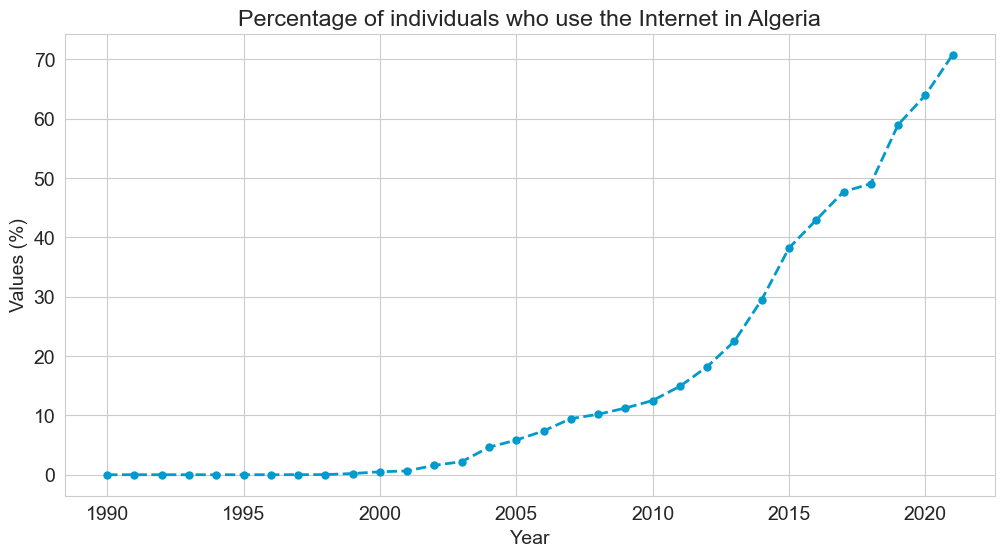

In [23]:
plt.figure(figsize=(12,6))
plt.title('Percentage of individuals who use the Internet in Algeria')
plt.xlabel('Year')
plt.ylabel(r'Values (%)')
users_df.Users_Percentage.plot(kind='line', color='#009ACD', marker='o', linestyle='dashed', linewidth=2, markersize=5)

<Axes: title={'center': 'Percentage of individuals who use the Internet in Algeria & The Maghreb Union'}, xlabel='Year', ylabel='Values (%)'>

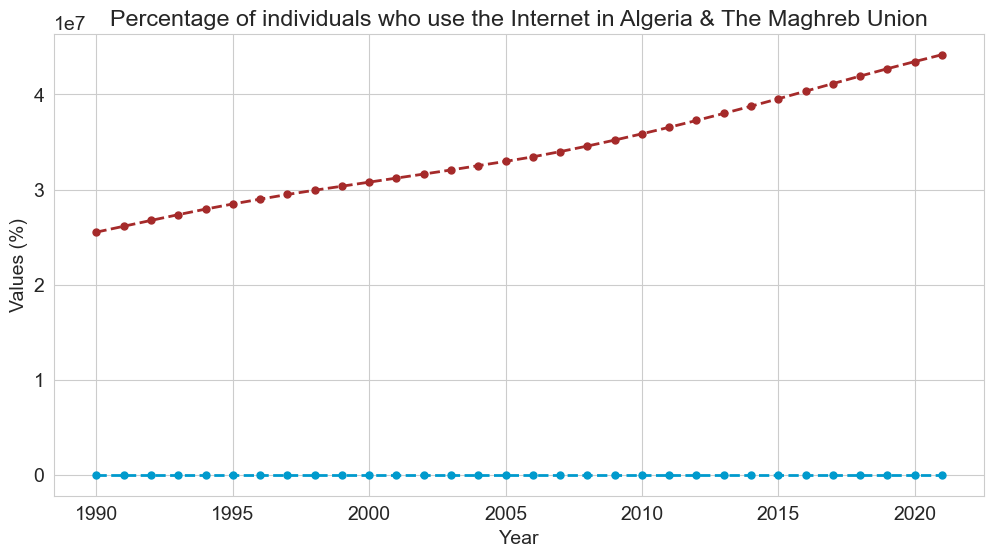

In [24]:
plt.figure(figsize=(12,6))
plt.title('Percentage of individuals who use the Internet in Algeria & The Maghreb Union')
plt.xlabel('Year')
plt.ylabel(r'Values (%)')
users_df.Users_Percentage.plot(kind='line', color='#009ACD', marker='o', linestyle='dashed', linewidth=2, markersize=5)
users_df.Total_population.plot(kind='line', color='brown', marker='o', linestyle='dashed', linewidth=2, markersize=5)

<Axes: title={'center': 'Percentage of individuals who use the Internet in Algeria & The Arab World'}, xlabel='Year', ylabel='Values (%)'>

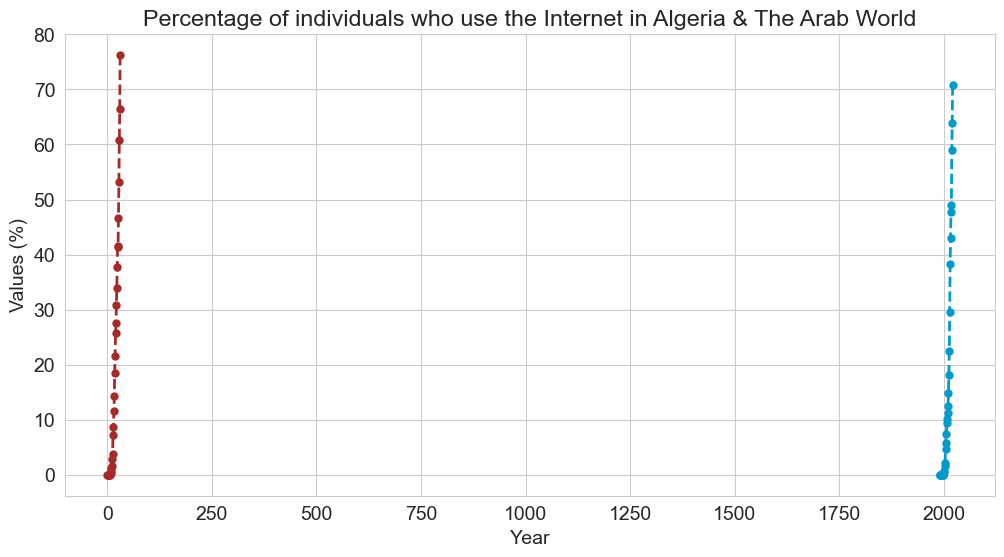

In [25]:
plt.figure(figsize=(12,6))
plt.title('Percentage of individuals who use the Internet in Algeria & The Arab World')
plt.xlabel('Year')
plt.ylabel(r'Values (%)')
users_df.Users_Percentage.plot(kind='line', color='#009ACD', marker='o', linestyle='dashed', linewidth=2, markersize=5)
indic_df.Arab_world.plot(kind='line', color='brown', marker='o', linestyle='dashed', linewidth=2, markersize=5)

In [26]:
users_df.dropna(how='all',axis=1,inplace=True)
display(users_df)

,Users_Percentage,Total_population,Fixed_telephone_subscriptions,Mobile_phone_subscriptions,GDP_per_capita_current_US_Dollar
Year,,,,,
1990,0.000000,25518074,812000,470,2431.551360
1991,0.000000,26133905,883120,4781,1749.286087
1992,0.000000,26748303,962247,4781,1794.623507
1993,0.000000,27354327,1068094,4781,1825.875097
1994,0.000361,27937006,1122409,1348,1522.825203
1995,0.001769,28478022,1176316,4691,1466.544680
1996,0.001739,28984634,1278142,11700,1619.532412
1997,0.010268,29476031,1400343,17400,1634.467410
1998,0.020239,29924668,1477000,18000,1610.302978


# Simple Regression

In [27]:
# indic_df.plot(kind="scatter")

In [28]:
regression_model = linear_model.LinearRegression()

# train
regression_model.fit(X = pd.DataFrame(users_df["Total_population"]), y = users_df["Users_Percentage"])

# check trained model y-intercept
print("Y-Intercept:")
print(regression_model.intercept_)
print("============================")

# check trained model coefficients
print("Model Coefficients: ")
print(regression_model.coef_)
print("============================")

# check score
print("Score: ", end="")
regression_model.score(X= pd.DataFrame(users_df["Total_population"]), y = users_df["Users_Percentage"])

Y-Intercept:
-108.68753628401302
Model Coefficients: 
[3.67435754e-06]
Score: 

0.8537550487287726

In [29]:
# train prediction
train_prediction = regression_model.predict(X = pd.DataFrame(users_df["Total_population"]))

# actual - prediction = residuals
residuals = users_df["Users_Percentage"] - train_prediction

print("Residuals :")
residuals.describe()

Residuals :


count    3.200000e+01
mean     1.665335e-15
std      8.280120e+00
min     -1.068650e+01
25%     -6.744732e+00
50%     -1.930727e+00
75%      5.430497e+00
max      1.713188e+01
Name: Users_Percentage, dtype: float64

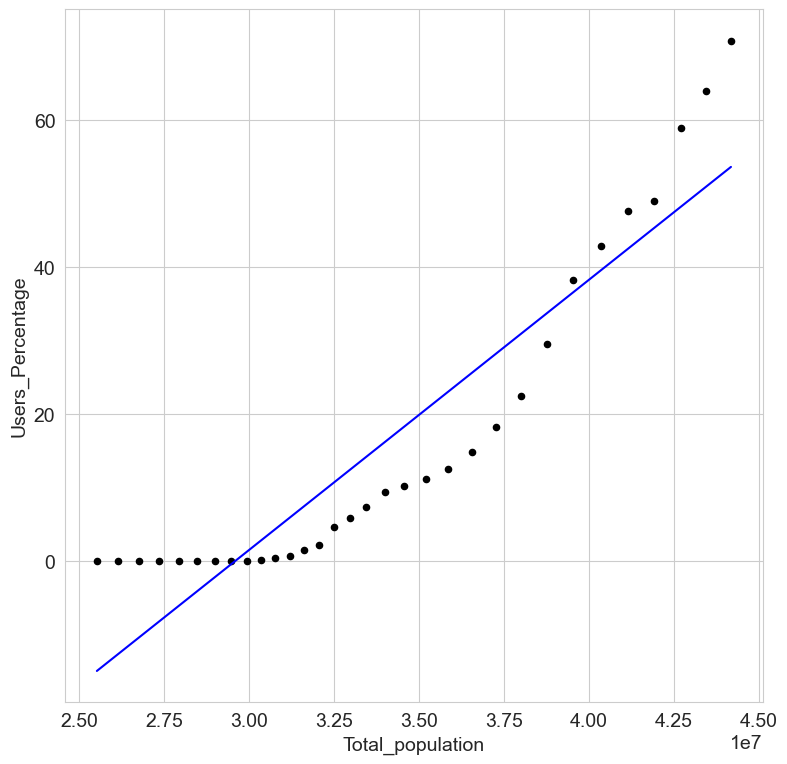

In [30]:
users_df.plot(kind="scatter", x="Total_population", y="Users_Percentage", figsize=(9,9), color="black")

# plot regression line
plt.plot(users_df["Total_population"], train_prediction, color="b")

## model in fixed_telephone_sub vs users_percentage

In [33]:
regression_model = linear_model.LinearRegression()

# train
regression_model.fit(X = pd.DataFrame(users_df["Fixed_telephone_subscriptions"]), y = users_df["Users_Percentage"])

# check trained model y-intercept
print("Y-Intercept:")
print(regression_model.intercept_)
print("============================")

# check trained model coefficients
print("Model Coefficients: ")
print(regression_model.coef_)
print("============================")

# check score
print("Score: ", end="")
regression_model.score(X= pd.DataFrame(users_df["Fixed_telephone_subscriptions"]), y = users_df["Users_Percentage"])

Y-Intercept:
-24.767870824823213
Model Coefficients: 
[1.62302003e-05]
Score: 

0.8247959819941855

In [34]:
# train prediction
train_prediction = regression_model.predict(X = pd.DataFrame(users_df["Fixed_telephone_subscriptions"]))

# actual - prediction = residuals
residuals = users_df["Users_Percentage"] - train_prediction

print("Residuals :")
residuals.describe()

Residuals :


count    3.200000e+01
mean     1.942890e-15
std      9.062921e+00
min     -1.558183e+01
25%     -7.586606e+00
50%      1.433198e+00
75%      7.701303e+00
max      1.281158e+01
Name: Users_Percentage, dtype: float64

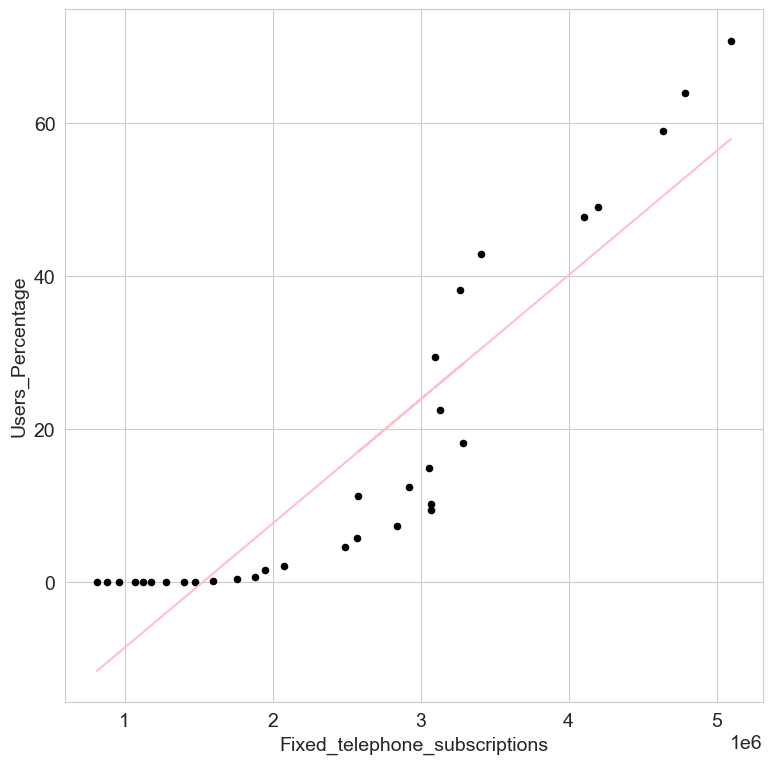

In [37]:
users_df.plot(kind="scatter", x="Fixed_telephone_subscriptions", y="Users_Percentage", figsize=(9,9), color="black")

# plot regression line
plt.plot(users_df["Fixed_telephone_subscriptions"], train_prediction, color="pink")

## mobile sub vs percentage